In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm, expon
from src.data import SimulatedData, Strategy
from src.matching import Matching
from src.evaluation import Evaluation
from tqdm import tqdm
from matplotlib.ticker import FormatStrFormatter

In [2]:
def normalize(y):
    return [(k - min(y))/(max(y) - min(y)) + 0.01 for k in y]

def get_prob(dist, n_items, n_agents, a=1):
    x = list(range(n_items))
    y = list(range(n_items))
    if dist == "uniform":
        y = [1/n_items] * len(x)
    elif dist == "linear":
        y = [(k*a + 1/n_agents) for k in x]
    elif dist == "exponential":
        y = [np.exp(k*a) + 1/n_agents for k in x]
    elif dist == "logistic":
        y = [-(1/(1-np.exp(-(k*a+1)))) - 1/n_agents for k in x]
    return x,normalize(y)

def get_demand(agents, items):
    demands = {i:[] for i in items[0]}
    n_agent = len(agents[0])
    for idx, agent in enumerate(agents):
        for i in demands:
            count = 0
            for pref in agent.values():
                if pref[0] == i:
                    count += 1
            demands[i].append(count)
    avg_demand = {i:(np.average(demands[i])/n_agent,np.std(demands[i])/n_agent) for i in demands}
    return avg_demand

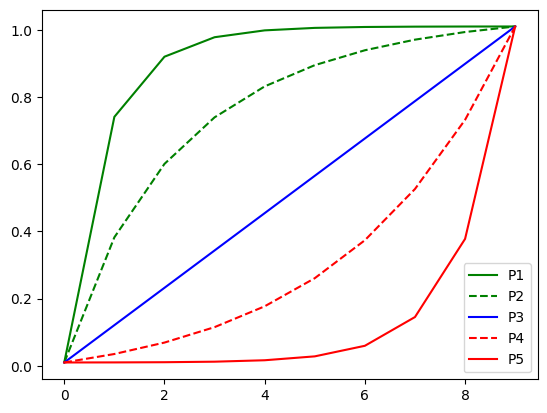

In [3]:
x, p1 = get_prob("logistic", 10, 100)
plt.plot(x,p1,'g-', label="P1")
x, p2 = get_prob("logistic", 10, 100,a=0.3)
plt.plot(x,p2,'g--', label="P2")
x, p3 = get_prob("linear", 10, 100)
plt.plot(x,p3,'b-', label="P3")
x, p4 = get_prob("exponential", 10, 100, a=0.3)
plt.plot(x,p4,'r--', label="P4")
x, p5 = get_prob("exponential", 10, 100)
plt.plot(x,p5,'r-', label="P5")
plt.legend()

In [4]:
N_AGENTS = 1000
N_ITEMS = 10

scenario_labels = ["Logistic", "Linear", "Exponential"]
scenarios = {label:{} for label in scenario_labels}

In [5]:
for label in scenario_labels:
    _, p = get_prob(label.lower(), N_ITEMS, N_AGENTS)
    scenarios[label]['demand'] = [k/sum(p) for k in p]
    scenarios[label]['agents'] = []
    scenarios[label]['items'] = []
    scenarios[label]['RSD'] = []
    scenarios[label]['RM-HAL'] = []

In [6]:
data = SimulatedData(seed=1610)
topns = [1, 2, 3, "Mixed-n"]
fractions = [1.0, .75, .50, .25]
DEFAULT_TOPN = "Mixed-n"
DEFAULT_FRACTION = 1.0
DEFAULT_STRATEGY = "FOH"
CUTOFF = False

In [7]:
for label in scenario_labels:
    for run in tqdm(range(50)):
        # generate simulated data
        agents, items, not_placed_id = data.generate_agents_and_items(n_agents=N_AGENTS, n_items=N_ITEMS, probabilities=scenarios[label]['demand'])
        scenarios[label]['agents'].append(agents)
        scenarios[label]['items'].append(items)
        scenarios[label]['Not Placed'] = not_placed_id

        # apply matching algorithms
        matching = Matching(agents=agents, items=items, not_placed_id=not_placed_id)
        # random priority
        scenarios[label]['RSD'].append(matching.random_priority())
        # hungarian algorithm
        scenarios[label]['RM-HAL'].append(matching.hungarian_algorithm())

        #strategy exp 1a
        strategy = Strategy(seed=2710, agents=agents, items=items, not_placed_id=not_placed_id)
        for topn in topns:
            slabel = f'RM-HAL, n={topn}'
            alabel = f'agents, n={topn}'
            strategic_agents, strategic_agent_ids = strategy.get_strategic_agents(stype=DEFAULT_STRATEGY, fraction=DEFAULT_FRACTION, topn=topn, topn_mode="uniform", cutoff=CUTOFF)
            matching_s = Matching(agents=strategic_agents, items=items, not_placed_id=not_placed_id)
            allocation_ha_s = matching_s.hungarian_algorithm()
            if slabel not in scenarios[label]:
                scenarios[label][slabel] = []
            if alabel not in scenarios[label]:
                scenarios[label][alabel] = []
            scenarios[label][slabel].append(allocation_ha_s)
            scenarios[label][alabel].append((strategic_agents, strategic_agent_ids))

        #strategy exp 1b
        for fraction in fractions:
            slabel = f'RM-HAL, f={int(fraction*100)}%'
            alabel = f'agents, f={int(fraction*100)}'
            strategic_agents, strategic_agent_ids = strategy.get_strategic_agents(stype=DEFAULT_STRATEGY, fraction=fraction, topn=DEFAULT_TOPN, topn_mode="uniform", cutoff=CUTOFF)
            matching_s = Matching(agents=strategic_agents, items=items, not_placed_id=not_placed_id)
            allocation_ha_s = matching_s.hungarian_algorithm()
            if slabel not in scenarios[label]:
                scenarios[label][slabel] = []
            if alabel not in scenarios[label]:
                scenarios[label][alabel] = []
            scenarios[label][slabel].append(allocation_ha_s)
            scenarios[label][alabel].append((strategic_agents, strategic_agent_ids))

        #strategy exp 2
        for topn in topns:
            slabel = f'RM-HAL, n={topn}'
            alabel = f'agents, n={topn} individual'
            strategic_agents, strategic_agent_ids = strategy.get_strategic_agents(stype=DEFAULT_STRATEGY, fraction=0.5, topn=topn, topn_mode="uniform", cutoff=CUTOFF)
            matching_s = Matching(agents=strategic_agents, items=items, not_placed_id=not_placed_id)

            allocation_ha_s = matching_s.hungarian_algorithm()
            allocation_ha_truth = {k:v for k,v in allocation_ha_s.items() if k not in strategic_agent_ids}
            allocation_ha_strat = {k:v for k,v in allocation_ha_s.items() if k in strategic_agent_ids}

            slabelt = slabel + ' truthful'
            slabelst = slabel + ' strategic'
            slabelb = slabel + ' baseline'

            if slabelt not in scenarios[label]:
                scenarios[label][slabelt] = []
            if slabelst not in scenarios[label]:
                scenarios[label][slabelst] = []
            if slabelb not in scenarios[label]:
                scenarios[label][slabelb] = []
            if alabel not in scenarios[label]:
                scenarios[label][alabel] = []

            scenarios[label][slabelt].append(allocation_ha_truth)
            scenarios[label][slabelst].append(allocation_ha_strat)
            scenarios[label][slabelb].append(allocation_ha_s)
            scenarios[label][alabel].append((strategic_agents, strategic_agent_ids))

100%|██████████| 50/50 [07:06<00:00,  8.53s/it]


In [8]:
import pickle
pickle.dump(scenarios, open('synth_data_seed_1610.pkl', 'wb'))